In [5]:
import random


# Etapa 2

# 1.

In [50]:
import numpy as np

rng = np.random.default_rng(2026)


for m in [20,25,30,35,40,45,50,60,70,80]:
    al_menos_una = False
    for s in range(10000):
        album = [0] * 100
        for n in range(m):
            for r in range(7):
                numero = rng.integers(0, 100)
                album[numero] = 1
    
        lleno = True
        for n in range(len(album)):
            if album[n] == 0:
                lleno = False
                break 
        if lleno:
                al_menos_una = True

    print(f"Sobres: {m} | Al menos una vez lleno: {al_menos_una}")



Sobres: 20 | Al menos una vez lleno: False
Sobres: 25 | Al menos una vez lleno: False
Sobres: 30 | Al menos una vez lleno: False
Sobres: 35 | Al menos una vez lleno: True
Sobres: 40 | Al menos una vez lleno: True
Sobres: 45 | Al menos una vez lleno: True
Sobres: 50 | Al menos una vez lleno: True
Sobres: 60 | Al menos una vez lleno: True
Sobres: 70 | Al menos una vez lleno: True
Sobres: 80 | Al menos una vez lleno: True


# 2.

In [79]:
rng = np.random.default_rng(2026)
m_valores = [20,25,30,35,40,45,50,60,70,80]
m_contador = [0]*10

for pos, m in enumerate(m_valores):
    contador = 0
    for s in range(10000):
        album = [0] * 100
        for n in range(m):
            for r in range(7):
                numero = rng.integers(0, 100)
                album[numero] = 1
    
        lleno = True
        for n in range(len(album)):
            if album[n] == 0:
                lleno = False
                break 
        if lleno:
            contador += 1
            m_contador[pos] += 1
    print(f"Sobres: {m}, Completado {contador} veces, proporcion: {(contador)/10000:.4f}")


Sobres: 20, Completado 0 veces, proporcion: 0.0000
Sobres: 25, Completado 0 veces, proporcion: 0.0000
Sobres: 30, Completado 0 veces, proporcion: 0.0000
Sobres: 35, Completado 1 veces, proporcion: 0.0001
Sobres: 40, Completado 6 veces, proporcion: 0.0006
Sobres: 45, Completado 82 veces, proporcion: 0.0082
Sobres: 50, Completado 355 veces, proporcion: 0.0355
Sobres: 60, Completado 2134 veces, proporcion: 0.2134
Sobres: 70, Completado 4702 veces, proporcion: 0.4702
Sobres: 80, Completado 6924 veces, proporcion: 0.6924


In [64]:
print(m_contador)

[0, 0, 0, 1, 6, 82, 355, 2134, 4702, 6924]


# 3.

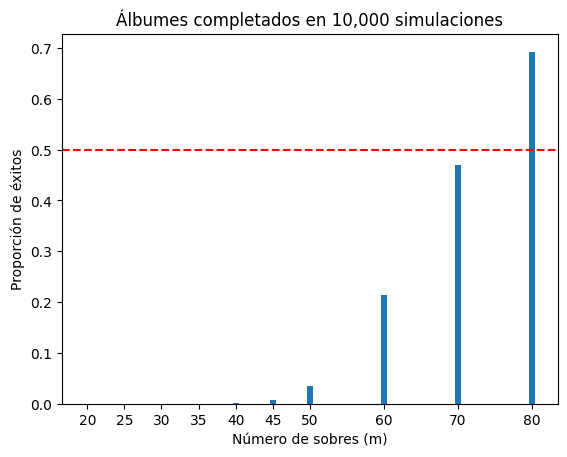

In [80]:
import matplotlib.pyplot as plt

m_valores = [20,25,30,35,40,45,50,60,70,80]

plt.bar(m_valores, [c/10000 for c in m_contador])
plt.xlabel("Número de sobres (m)")
plt.ylabel("Proporción de éxitos")
plt.title("Álbumes completados en 10,000 simulaciones")
plt.xticks(m_valores)
plt.axhline(y=0.5, color='red', linestyle='--')

plt.show()

#Grafico generado con ayuda de Claude

# Preguntas de analisis

# 1.

In [70]:
m_valores = range(70, 120, 5)
m_resultados = []

for m in m_valores:
    contador = 0
    for s in range(10000):
        album = [0] * 100
        for n in range(m):
            for r in range(7):
                numero = rng.integers(0, 100)
                album[numero] = 1
        lleno = True
        for n in range(len(album)):
            if album[n] == 0:
                lleno = False
                break
        if lleno:
            contador += 1
    proporcion = contador/10000
    m_resultados.append(proporcion)
    
    if proporcion >= 0.50 and not any(r >= 0.50 for r in m_resultados[:-1]):
        print(f"Supera 50% en m={m} ({proporcion:.4f})")
    if proporcion >= 0.90 and not any(r >= 0.90 for r in m_resultados[:-1]):
        print(f"Supera 90% en m={m} ({proporcion:.4f})")

#Claude me ayudo con la condicional "and not any(r >= 0.50 for r in m_resultados[:-1]):" para no repetir impresiones

Supera 50% en m=75 (0.5927)
Supera 90% en m=100 (0.9151)


# 2.

In [73]:
m_esperado_50 = 100/7 * (np.log(100) + 0.5772)
print(m_esperado_50)

74.0338597998299


El valor calculado y teorico son bastante similares, esto es porque 10,000 simulaciones fueron suficientes para aproximarse el valor esperado

# 3.N, S, M = 100, 7, 50
cota = N * np.exp(-M * S / N)
print(f"Cota superior: {cota:.4f}")
print(f"Probabilidad simulada de fallar: {1 - proporcion_m50:.4f}")

In [78]:
N = 100
S = 7
M = 50

cota = N * np.exp(-M * S / N)

proporcion_m50 = m_resultados[6]

print(f"Cota superior:          {cota:.4f}")
print(f"Proporción simulada de fallo:    {1 - proporcion_m50:.4f}")
print(f"Proporción simulada de éxito:    {proporcion_m50:.4f}")

Cota superior:          3.0197
Proporción simulada de fallo:    0.0849
Proporción simulada de éxito:    0.9151


La cota no es util, por el tamaño de los datos la exponencial no cae y no logra aproximar bien la realidad